# Financial Transaction Fraud Analysis
This notebook performs exploratory data analysis and fraud insights on the cleaned transaction dataset.

Steps covered:
1. Load processed dataset
2. Explore dataset structure
3. Fraud vs Normal transaction analysis
4. Transaction amount distribution
5. Merchant transaction analysis
6. Daily transaction volume
7. Fraud by merchant
8. KPI summary metrics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Processed Dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Lytora Analytix\Projects\Financial Transaction System\financial-transaction-cleanup\data\processed\fraud_checked_transactions.csv")

df.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_1288\2561562904.py:3: DtypeWarning: Columns (0,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Lytora Analytix\Projects\Financial Transaction System\financial-transaction-cleanup\data\processed\fraud_checked_transactions.csv")


,trans_date_trans_time,merchant,category,amt,gender,city_pop,is_fraud,hour,day,month,day_of_week,is_refund,is_anomaly,high_risk_merchant,fraud_prediction
0,2019-01-01 00:00:00,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,3495,0,0.0,1.0,1.0,Tuesday,False,False,False,Normal
1,2019-01-01 00:00:00,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,149,0,0.0,1.0,1.0,Tuesday,False,False,False,Normal
2,2019-01-01 00:00:00,fraud_Lind-Buckridge,entertainment,220.11,M,4154,0,0.0,1.0,1.0,Tuesday,False,True,False,Normal
3,2019-01-01 00:01:00,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,1939,0,0.0,1.0,1.0,Tuesday,False,False,False,Normal
4,2019-01-01 00:03:00,fraud_Keeling-Crist,misc_pos,41.96,M,99,0,0.0,1.0,1.0,Tuesday,False,False,False,Normal


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048440 entries, 0 to 1048439
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  426217 non-null   object 
 1   merchant               1048440 non-null  object 
 2   category               1048440 non-null  object 
 3   amt                    1048440 non-null  float64
 4   gender                 1048440 non-null  object 
 5   city_pop               1048440 non-null  int64  
 6   is_fraud               1048440 non-null  int64  
 7   hour                   426217 non-null   float64
 8   day                    426217 non-null   float64
 9   month                  426217 non-null   float64
 10  day_of_week            426217 non-null   object 
 11  is_refund              1048440 non-null  bool   
 12  is_anomaly             1048440 non-null  bool   
 13  high_risk_merchant     1048440 non-null  bool   
 14  fraud_prediction  

In [4]:
df.describe()

,amt,city_pop,is_fraud,hour,day,month
count,1.048440e+06,1.048440e+06,1.048440e+06,426217.000000,426217.000000,426217.000000
mean,7.028432e+01,8.906348e+04,5.728511e-03,12.794377,6.346525,6.380731
std,1.599609e+02,3.024499e+05,7.546987e-02,6.819515,3.664446,3.449067
min,1.000000e+00,2.300000e+01,0.000000e+00,0.000000,1.000000,1.000000
25%,9.650000e+00,7.430000e+02,0.000000e+00,7.000000,3.000000,3.000000
50%,4.745000e+01,2.456000e+03,0.000000e+00,14.000000,6.000000,6.000000
75%,8.306000e+01,2.032800e+04,0.000000e+00,19.000000,10.000000,9.000000
max,2.894890e+04,2.906700e+06,1.000000e+00,23.000000,12.000000,12.000000


## Fraud vs Normal Transactions

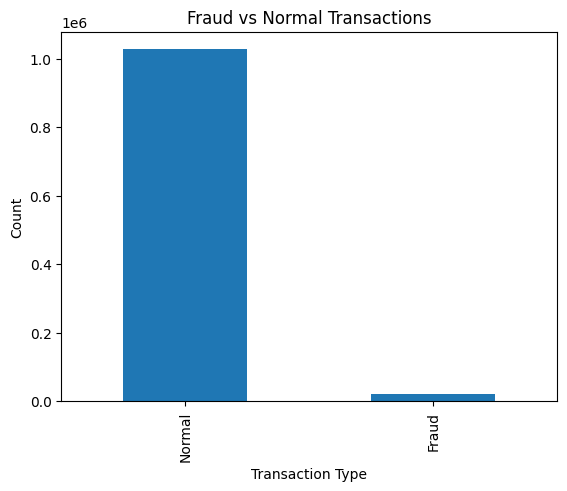

In [5]:
fraud_counts = df['fraud_prediction'].value_counts()

plt.figure()
fraud_counts.plot(kind='bar')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

## Transaction Amount Distribution

In [6]:
plt.figure()
df['amount'].hist(bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

KeyError: 'amount'

<Figure size 640x480 with 0 Axes>

## Transaction Amounts by Fraud Status

In [ ]:
plt.figure()
sns.boxplot(x='fraud_prediction', y='amount', data=df)
plt.title('Transaction Amount by Fraud Status')
plt.show()

## Top Merchants by Transaction Count

In [ ]:
top_merchants = df['merchant'].value_counts().head(10)

plt.figure()
top_merchants.plot(kind='bar')
plt.title('Top Merchants by Transaction Volume')
plt.xlabel('Merchant')
plt.ylabel('Transactions')
plt.show()

## Daily Transaction Volume

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

daily_tx = df.groupby('date').size()

plt.figure()
daily_tx.plot()
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.show()

## Fraud Transactions by Merchant

In [ ]:
fraud_merchants = df[df['fraud_prediction']=='Fraud']['merchant'].value_counts().head(10)

plt.figure()
fraud_merchants.plot(kind='bar')
plt.title('Merchants with Most Fraud Transactions')
plt.xlabel('Merchant')
plt.ylabel('Fraud Transactions')
plt.show()

## Fraud KPI Summary

In [ ]:
total_transactions = len(df)
fraud_transactions = (df['fraud_prediction']=='Fraud').sum()
fraud_rate = fraud_transactions / total_transactions * 100

print('Total Transactions:', total_transactions)
print('Fraud Transactions:', fraud_transactions)
print('Fraud Rate:', round(fraud_rate,2), '%')